In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

file_path = "C:/Users/Super/PycharmProjects/MSiD/resources/student_mental_health_burnout.csv"

df = pd.read_csv(file_path, )

# Testing and checking for invalid data
print("First 5 records:", df.head())

print(df.info())

pd.set_option('display.max_columns', None)
print(df.describe())

First 5 records:    student_id  age  gender course year  daily_study_hours  daily_sleep_hours  \
0      100001   23    Male  BTech  1st                4.3                6.8   
1      100002   20    Male  BTech  3rd                1.4                4.7   
2      100003   24  Female    BCA  4th                3.7                4.8   
3      100004   21    Male    BSc  4th                1.6                6.7   
4      100005   23   Other    BSc  4th                2.0                6.7   

   screen_time_hours stress_level  anxiety_score  depression_score  \
0                6.1         High             10                 3   
1                3.0         High              2                10   
2                1.5          Low              2                 7   
3                7.0         High              3                 3   
4                5.4         High              7                 7   

   academic_pressure_score  financial_stress_score  social_support_score  \
0    

Text(0, 0.5, 'Liczność')

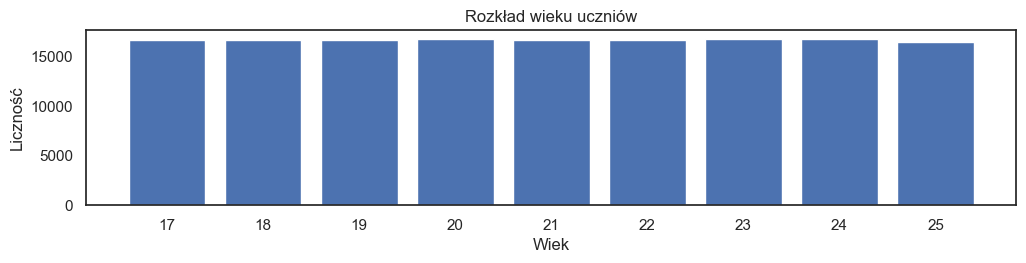

In [13]:
# Visualization
sns.set_theme(style="white")
plt.figure(figsize=(12, 5))

age_plot = plt.subplot(2, 1, 1)
age_plot.bar(df['age'].unique(), df['age'].value_counts())
plt.xticks(ticks=df['age'].unique())
# sns.catplot(df['age'].dropna(), color='skyblue')
plt.title('Rozkład wieku uczniów')
plt.xlabel('Wiek')
plt.ylabel('Liczność')

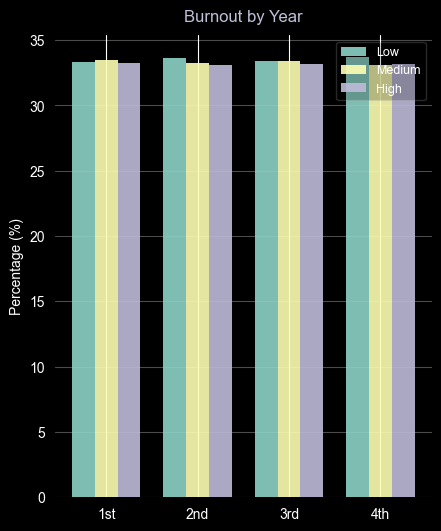

In [12]:
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

w = 0.25

ax3 = fig.add_subplot(gs[1])
burnout_year = df.groupby(['year','burnout_level']).size().unstack(fill_value=0)
order = ['1st','2nd','3rd','4th']
burnout_year = burnout_year.reindex(order)
burnout_year_pct = burnout_year.div(burnout_year.sum(axis=1), axis=0) * 100
x = np.arange(len(burnout_year_pct))
for i, level in enumerate(['Low','Medium','High']):
    ax3.bar(x + i*w, burnout_year_pct[level], w, label=level, alpha=0.9, edgecolor='none')
ax3.set_xticks(x + w)
ax3.set_xticklabels(order)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Burnout by Year', color='#c0c0d8', pad=10)
ax3.legend(framealpha=0.2, fontsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right','left','bottom']].set_visible(False)

In [ ]:
fig1 = plt.figure(figsize=(18, 6))
gs = GridSpec(2, 3, figure=fig1, wspace=0.35)

fig1.add_subplot(gs[0])
